# EDA - Perfil do Publico (Home Credit)

**Base:** `application_train.csv` + `previous_application.csv`
**Objetivo:** traçar o perfil do público atendido pela Home Credit — quem são os clientes, como se distribuem em termos demográficos e socioeconômicos, qual a taxa de inadimplência por segmento e, cruzando com o histórico de propostas, qual a taxa de aprovação por produto e por perfil de cliente.

Este notebook é complementar ao `EDA_HomeCredit.ipynb` (focado na estrutura da base e nos scores para modelagem). Aqui o foco é de negócio: caracterização de público, indicadores sensíveis e comparação de taxas entre segmentos.

**Roteiro do notebook:**

    1. Carga dos dados
    2. Preparação de variáveis (faixas etárias, faixas de renda, faixas de filhos)
    3. Visão geral do público (dashboard de indicadores)
    4. Perfil demográfico (gênero, idade, renda, escolaridade, filhos, bens, moradia)
    5. Inadimplência por segmento
    6. Funil de aprovação (previous_application)
    7. Aprovação x Risco (cruzamento das duas análises)
    8. Conclusões e próximos passos

## 1. Import e configuração

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

sns.set_theme(style='whitegrid')

# Paleta base: mesma linguagem visual do EDA_HomeCredit.ipynb
# steelblue = favorável / adimplente / aprovado | indianred = desfavorável / inadimplente / recusado
COR_BOM = 'steelblue'
COR_MAU = 'indianred'
COR_NEUTRA = '#9a9a9a'
COR_ALERTA = '#d9a441'

PALETA_CATEGORICA = sns.color_palette('colorblind')


def paleta_ordinal(n, cor=COR_BOM):
    # rampa sequencial (claro -> escuro) para variáveis ordinais (faixas, escolaridade)
    return sns.light_palette(cor, n_colors=n + 2)[2:]

Funções auxiliares reutilizadas ao longo do notebook (tabela de taxa por grupo, gráfico de desvio vs. média e dashboard de indicadores).

In [2]:
# Taxa média (%) e volume de uma coluna binária (0/1) por categoria
def taxa_por_grupo(df, coluna, target='TARGET'):
    g = df.groupby(coluna, observed=True)[target].agg(['mean', 'count'])
    g['taxa_pct'] = (g['mean'] * 100).round(2)
    g = g.rename(columns={'count': 'n'}).drop(columns='mean')
    return g.sort_values('taxa_pct', ascending=False)


# Barras horizontais com o desvio de cada categoria vs. a média geral (pp)
# acima_e_bom=True  -> categoria acima da média é favorável (ex: taxa de aprovação)
# acima_e_bom=False -> categoria acima da média é desfavorável (ex: taxa de inadimplência)
def grafico_diferenca_media(serie, media_geral, titulo, xlabel, acima_e_bom=True, figsize=(8, 4.5)):
    diff = (serie - media_geral).sort_values()
    if acima_e_bom:
        cores = [COR_MAU if v < 0 else COR_BOM for v in diff.values]
        rotulo_bom = 'Favorável (acima da média)'
    else:
        cores = [COR_BOM if v < 0 else COR_MAU for v in diff.values]
        rotulo_bom = 'Favorável (abaixo da média)'

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(diff.index.astype(str), diff.values, color=cores)
    ax.axvline(0, color='#444444', linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel(f'{xlabel} — desvio vs. média geral ({media_geral:.1f}%), em pontos percentuais')
    ax.set_ylabel('')

    span = max(abs(diff.min()), abs(diff.max()), 0.5)
    ax.set_xlim(diff.min() - span * 0.25, diff.max() + span * 0.25)
    for i, v in enumerate(diff.values):
        deslocamento = span * 0.03
        ax.text(v + (deslocamento if v >= 0 else -deslocamento), i, f'{v:+.1f}pp',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

    legenda = [Patch(facecolor=COR_BOM, label=rotulo_bom), Patch(facecolor=COR_MAU, label='Desfavorável')]
    ax.legend(handles=legenda, loc='lower right', frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


# Grade de indicadores em destaque (estilo dashboard) a partir de [(valor, rotulo), ...]
def kpi_dashboard(kpis, ncols=3, figsize=None):
    n = len(kpis)
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (ncols * 3.4, nrows * 2.3)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, (valor, rotulo) in zip(axes, kpis):
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0.03, 0.06), 0.94, 0.88, transform=ax.transAxes,
                                    fill=False, edgecolor='#dddddd', linewidth=1.2))
        ax.text(0.5, 0.60, valor, ha='center', va='center', fontsize=19, fontweight='bold', color='#1f3b57')
        ax.text(0.5, 0.24, rotulo, ha='center', va='center', fontsize=10, color='#555555')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 2. Carga dos dados

In [3]:
app_path = r'C:\Users\muril\OneDrive\Desktop\Fonte\application_train.csv'
prev_path = r'C:\Users\muril\OneDrive\Desktop\Fonte\previous_application.csv'

colunas_app = [
    'SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'OWN_CAR_AGE',
]
df = pd.read_csv(app_path, sep=',', usecols=colunas_app)

print(f'df: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

df: 307511 linhas x 15 colunas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,OWN_CAR_AGE,CNT_FAM_MEMBERS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,Secondary / secondary special,Single / not married,House / apartment,-9461,NaN,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,Higher education,Married,House / apartment,-16765,NaN,2.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,Secondary / secondary special,Single / not married,House / apartment,-19046,26.0,1.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,Secondary / secondary special,Civil marriage,House / apartment,-19005,NaN,2.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,Secondary / secondary special,Single / not married,House / apartment,-19932,NaN,1.0


## 3. Preparação de variáveis

Idade, faixas de renda, faixas de filhos e rótulos legíveis para as variáveis categóricas que serão usadas nas análises de público.

In [4]:
# Idade em anos (DAYS_BIRTH é negativo, em dias, a partir da data da proposta)
df['IDADE'] = -df['DAYS_BIRTH'] / 365.25

bins_idade = [18, 25, 35, 45, 55, 65, 100]
labels_idade = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['FAIXA_ETARIA'] = pd.cut(df['IDADE'], bins=bins_idade, labels=labels_idade)

# Faixas de renda em cortes redondos (a variável é muito assimétrica: mediana ~147k, máximo ~117M)
bins_renda = [0, 100_000, 150_000, 200_000, 300_000, np.inf]
labels_renda = ['Até 100k', '100k-150k', '150k-200k', '200k-300k', '300k+']
df['FAIXA_RENDA'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=bins_renda, labels=labels_renda)

# Filhos: agrupa 3 ou mais em uma única faixa (cauda longa e pouco representativa isoladamente)
df['FAIXA_FILHOS'] = df['CNT_CHILDREN'].clip(upper=3).map({0: '0', 1: '1', 2: '2', 3: '3+'})

# Rótulos legíveis
df['SEXO'] = df['CODE_GENDER'].map({'F': 'Feminino', 'M': 'Masculino', 'XNA': 'Não informado'})
df['TEM_CARRO'] = df['FLAG_OWN_CAR'].map({'Y': 'Sim', 'N': 'Não'})
df['TEM_IMOVEL'] = df['FLAG_OWN_REALTY'].map({'Y': 'Sim', 'N': 'Não'})

# Escolaridade como categórica ordenada (do menor para o maior nível de instrução)
ordem_escolaridade = ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher',
                       'Higher education', 'Academic degree']
df['NAME_EDUCATION_TYPE'] = pd.Categorical(df['NAME_EDUCATION_TYPE'], categories=ordem_escolaridade, ordered=True)

df[['IDADE', 'FAIXA_ETARIA', 'FAIXA_RENDA', 'FAIXA_FILHOS', 'SEXO', 'TEM_CARRO', 'TEM_IMOVEL']].head()

,IDADE,FAIXA_ETARIA,FAIXA_RENDA,FAIXA_FILHOS,SEXO,TEM_CARRO,TEM_IMOVEL
0,25.902806,26-35,200k-300k,0,Masculino,Não,Sim
1,45.900068,46-55,200k-300k,0,Feminino,Não,Não
2,52.145106,46-55,Até 100k,0,Masculino,Sim,Sim
3,52.032854,46-55,100k-150k,0,Feminino,Não,Sim
4,54.570842,46-55,100k-150k,0,Masculino,Não,Sim


## 4. Visão geral do público

Painel com os principais indicadores do público analisado.

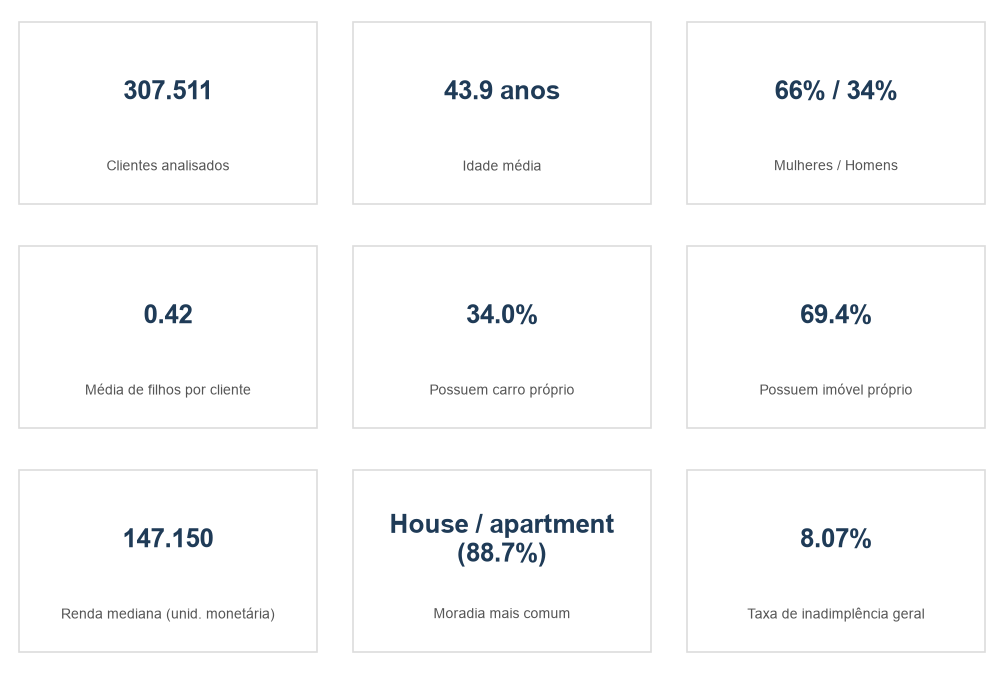

In [5]:
n_clientes = len(df)
taxa_inad_geral = df['TARGET'].mean() * 100
idade_media = df['IDADE'].mean()
pct_fem = (df['SEXO'] == 'Feminino').mean() * 100
pct_masc = (df['SEXO'] == 'Masculino').mean() * 100
pct_carro = (df['TEM_CARRO'] == 'Sim').mean() * 100
pct_imovel = (df['TEM_IMOVEL'] == 'Sim').mean() * 100
media_filhos = df['CNT_CHILDREN'].mean()
renda_mediana = df['AMT_INCOME_TOTAL'].median()
moradia_top = df['NAME_HOUSING_TYPE'].value_counts(normalize=True)
moradia_top_nome, moradia_top_pct = moradia_top.index[0], moradia_top.iloc[0] * 100

kpis = [
    (f"{n_clientes:,}".replace(',', '.'), 'Clientes analisados'),
    (f'{idade_media:.1f} anos', 'Idade média'),
    (f'{pct_fem:.0f}% / {pct_masc:.0f}%', 'Mulheres / Homens'),
    (f'{media_filhos:.2f}', 'Média de filhos por cliente'),
    (f'{pct_carro:.1f}%', 'Possuem carro próprio'),
    (f'{pct_imovel:.1f}%', 'Possuem imóvel próprio'),
    (f"{renda_mediana:,.0f}".replace(',', '.'), 'Renda mediana (unid. monetária)'),
    (f'{moradia_top_nome}\n({moradia_top_pct:.1f}%)', 'Moradia mais comum'),
    (f'{taxa_inad_geral:.2f}%', 'Taxa de inadimplência geral'),
]

kpi_dashboard(kpis, ncols=3)

## 5. Perfil demográfico

### 5.1 Gênero e estado civil

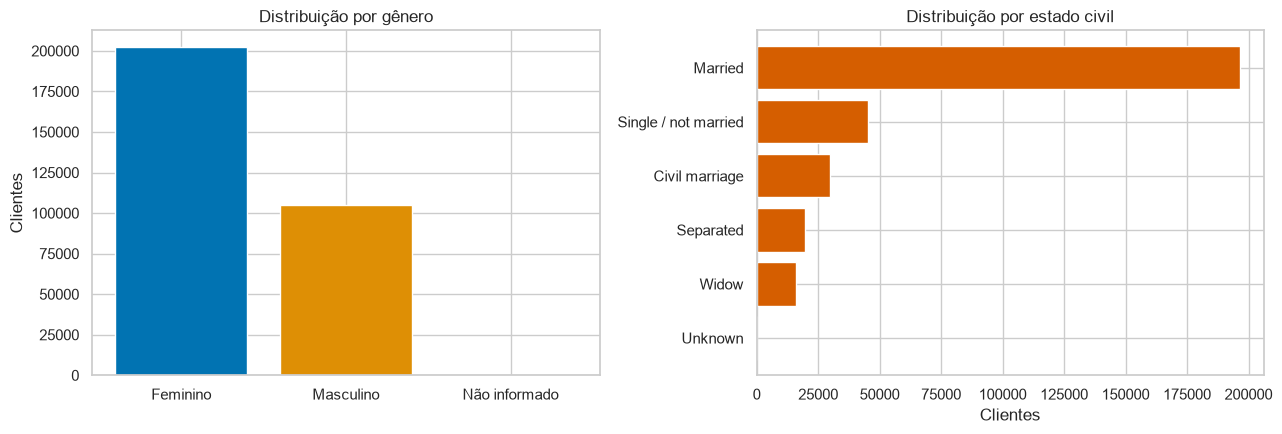

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ordem_sexo = ['Feminino', 'Masculino', 'Não informado']
contagem_sexo = df['SEXO'].value_counts().reindex(ordem_sexo).dropna()
axes[0].bar(contagem_sexo.index, contagem_sexo.values, color=PALETA_CATEGORICA[:len(contagem_sexo)])
axes[0].set_title('Distribuição por gênero')
axes[0].set_ylabel('Clientes')

contagem_civil = df['NAME_FAMILY_STATUS'].value_counts()
axes[1].barh(contagem_civil.index[::-1], contagem_civil.values[::-1], color=PALETA_CATEGORICA[3])
axes[1].set_title('Distribuição por estado civil')
axes[1].set_xlabel('Clientes')

plt.tight_layout()
plt.show()

### 5.2 Idade

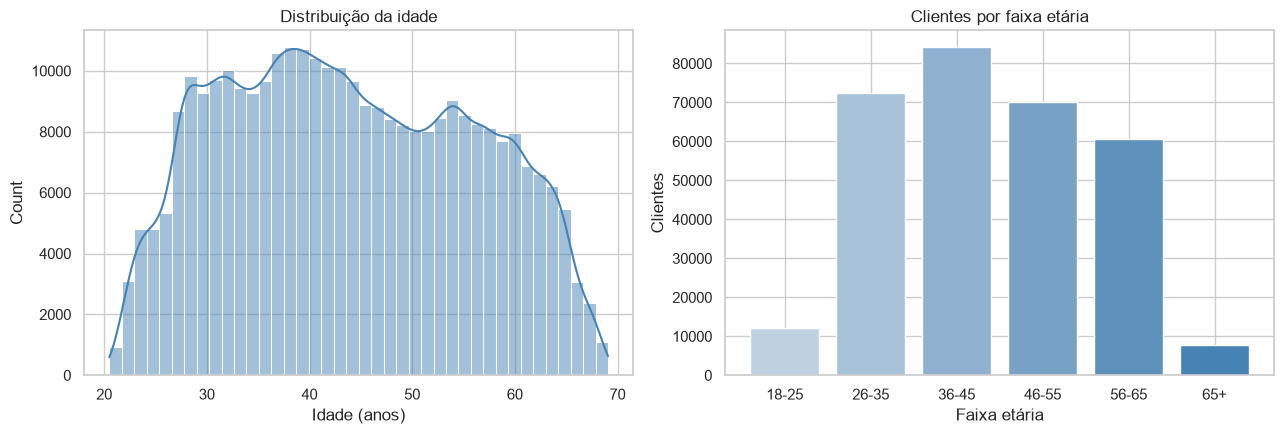

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['IDADE'], bins=40, kde=True, ax=axes[0], color=COR_BOM)
axes[0].set_title('Distribuição da idade')
axes[0].set_xlabel('Idade (anos)')

contagem_idade = df['FAIXA_ETARIA'].value_counts().reindex(labels_idade)
cores_idade = paleta_ordinal(len(labels_idade))
axes[1].bar(contagem_idade.index, contagem_idade.values, color=cores_idade)
axes[1].set_title('Clientes por faixa etária')
axes[1].set_xlabel('Faixa etária')
axes[1].set_ylabel('Clientes')

plt.tight_layout()
plt.show()

### 5.3 Renda

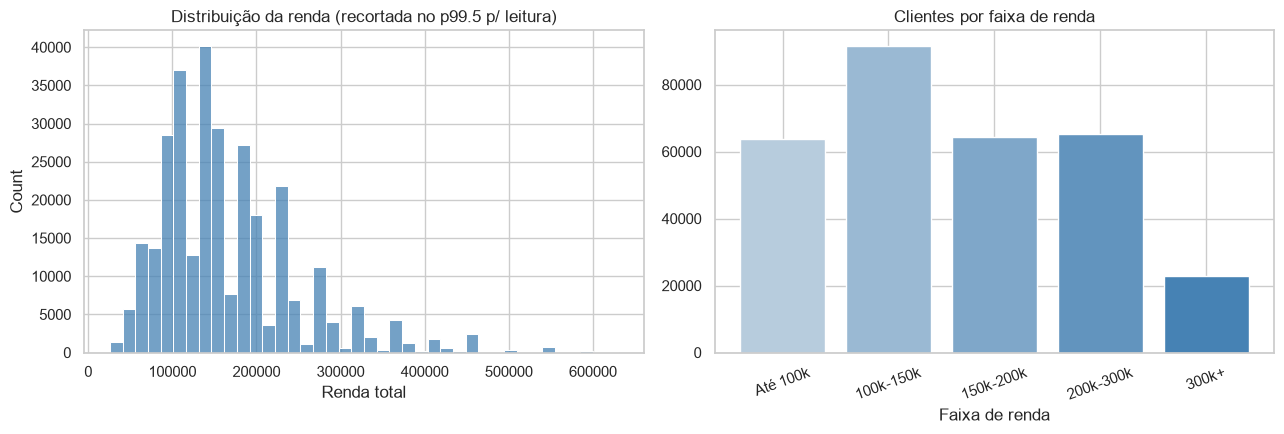

,count,min,median,max
FAIXA_RENDA,,,,
Até 100k,63698,25650.0,81000.0,99900.0
100k-150k,91591,100071.0,126000.0,149850.0
150k-200k,64307,150039.0,171000.0,199800.0
200k-300k,65176,200025.0,225000.0,299700.0
300k+,22739,300150.0,360000.0,117000000.0


In [8]:
p995 = df['AMT_INCOME_TOTAL'].quantile(0.995)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df.loc[df['AMT_INCOME_TOTAL'] <= p995, 'AMT_INCOME_TOTAL'], bins=40, ax=axes[0], color=COR_BOM)
axes[0].set_title('Distribuição da renda (recortada no p99.5 p/ leitura)')
axes[0].set_xlabel('Renda total')

contagem_renda = df['FAIXA_RENDA'].value_counts().reindex(labels_renda)
cores_renda = paleta_ordinal(len(labels_renda))
axes[1].bar(contagem_renda.index, contagem_renda.values, color=cores_renda)
axes[1].set_title('Clientes por faixa de renda')
axes[1].set_xlabel('Faixa de renda')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

df.groupby('FAIXA_RENDA', observed=True)['AMT_INCOME_TOTAL'].agg(['count', 'min', 'median', 'max']).round(0)

### 5.4 Escolaridade

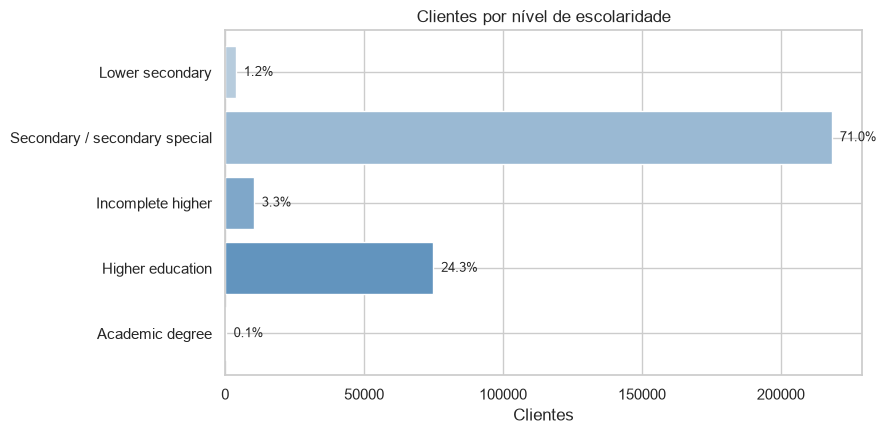

In [8]:
contagem_edu = df['NAME_EDUCATION_TYPE'].value_counts().reindex(ordem_escolaridade)
cores_edu = paleta_ordinal(len(ordem_escolaridade))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(contagem_edu.index[::-1], contagem_edu.values[::-1], color=cores_edu[::-1])
ax.set_title('Clientes por nível de escolaridade')
ax.set_xlabel('Clientes')
for i, v in enumerate(contagem_edu.values[::-1]):
    ax.text(v, i, f'  {v/len(df)*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.5 Filhos

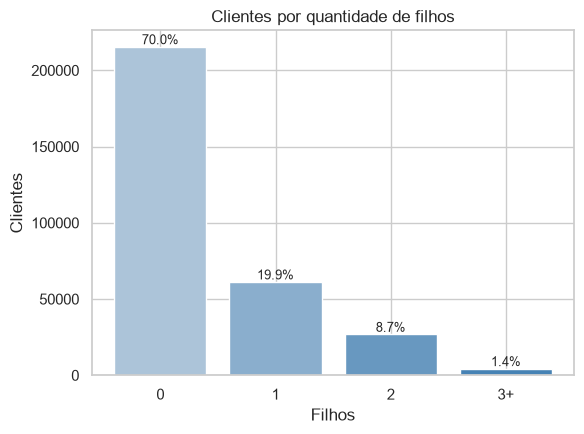

In [9]:
ordem_filhos = ['0', '1', '2', '3+']
contagem_filhos = df['FAIXA_FILHOS'].value_counts().reindex(ordem_filhos)
cores_filhos = paleta_ordinal(len(ordem_filhos))

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(contagem_filhos.index, contagem_filhos.values, color=cores_filhos)
ax.set_title('Clientes por quantidade de filhos')
ax.set_xlabel('Filhos')
ax.set_ylabel('Clientes')
for i, v in enumerate(contagem_filhos.values):
    ax.text(i, v, f'{v/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 5.6 Bens: carro e imóvel

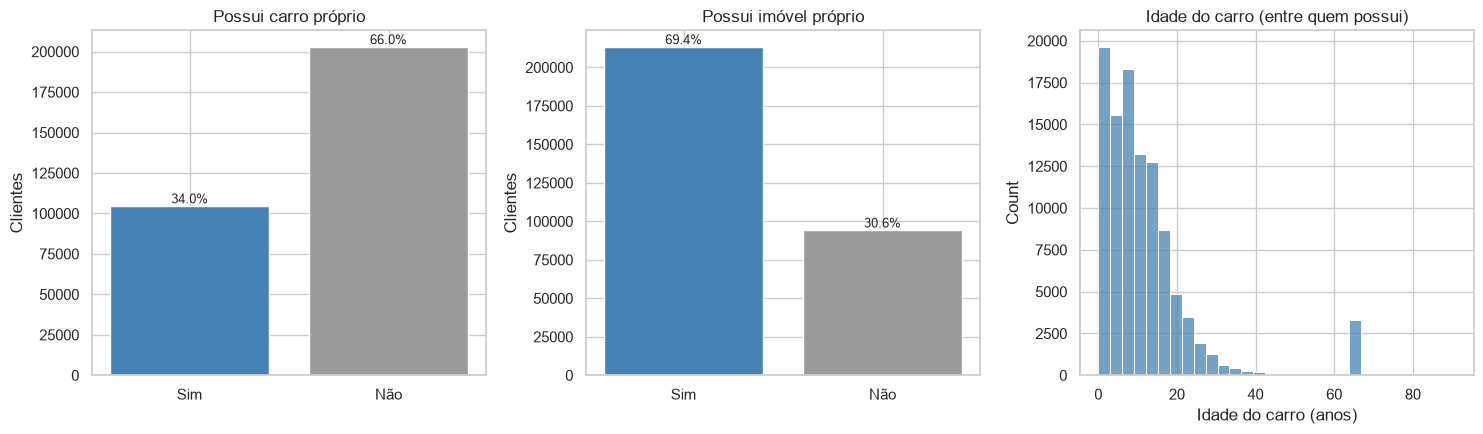

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, titulo in zip(axes[:2], ['TEM_CARRO', 'TEM_IMOVEL'], ['Possui carro próprio', 'Possui imóvel próprio']):
    contagem = df[col].value_counts().reindex(['Sim', 'Não'])
    ax.bar(contagem.index, contagem.values, color=[COR_BOM, COR_NEUTRA])
    ax.set_title(titulo)
    ax.set_ylabel('Clientes')
    for i, v in enumerate(contagem.values):
        ax.text(i, v, f'{v/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)

sns.histplot(df.loc[df['TEM_CARRO'] == 'Sim', 'OWN_CAR_AGE'], bins=30, ax=axes[2], color=COR_BOM)
axes[2].set_title('Idade do carro (entre quem possui)')
axes[2].set_xlabel('Idade do carro (anos)')

plt.tight_layout()
plt.show()

### 5.7 Tipo de moradia

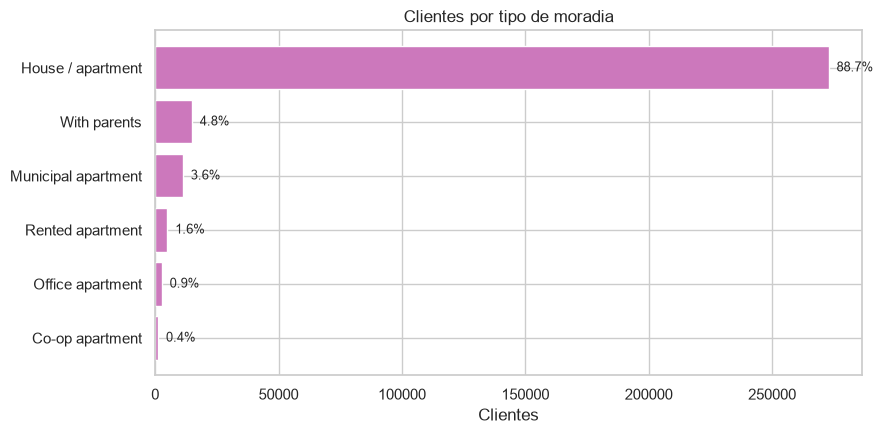

In [11]:
contagem_moradia = df['NAME_HOUSING_TYPE'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(contagem_moradia.index[::-1], contagem_moradia.values[::-1], color=PALETA_CATEGORICA[4])
ax.set_title('Clientes por tipo de moradia')
ax.set_xlabel('Clientes')
for i, v in enumerate(contagem_moradia.values[::-1]):
    ax.text(v, i, f'  {v/len(df)*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Inadimplência por segmento

Como cada recorte de público se compara à taxa de inadimplência geral (calculada na seção 4). Nos gráficos de desvio: barras à direita da linha zero = taxa acima da média; à esquerda = abaixo da média.

### 6.1 Por escolaridade

,n,taxa_pct
NAME_EDUCATION_TYPE,,
Lower secondary,3816,10.93
Secondary / secondary special,218391,8.94
Incomplete higher,10277,8.48
Higher education,74863,5.36
Academic degree,164,1.83


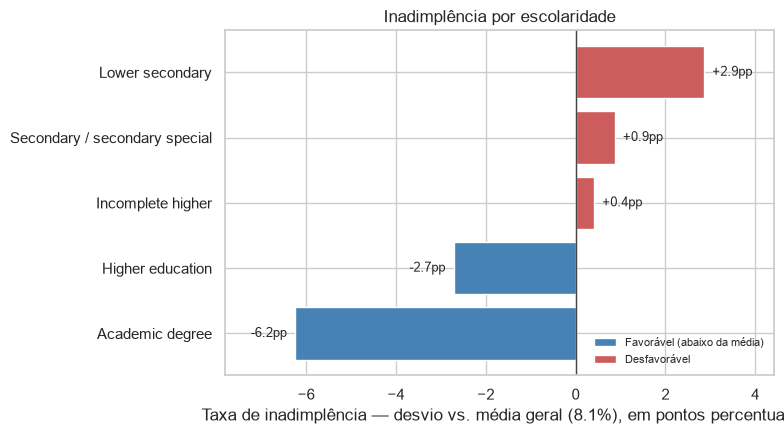

In [12]:
tab_edu_inad = taxa_por_grupo(df, 'NAME_EDUCATION_TYPE')
display(tab_edu_inad)
grafico_diferenca_media(tab_edu_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por escolaridade', 'Taxa de inadimplência', acima_e_bom=False)

### 6.2 Por faixa etária

,n,taxa_pct
FAIXA_ETARIA,,
18-25,12233,12.29
26-35,72429,10.66
36-45,84261,8.41
46-55,70190,7.05
56-65,60522,5.42
65+,7876,3.66


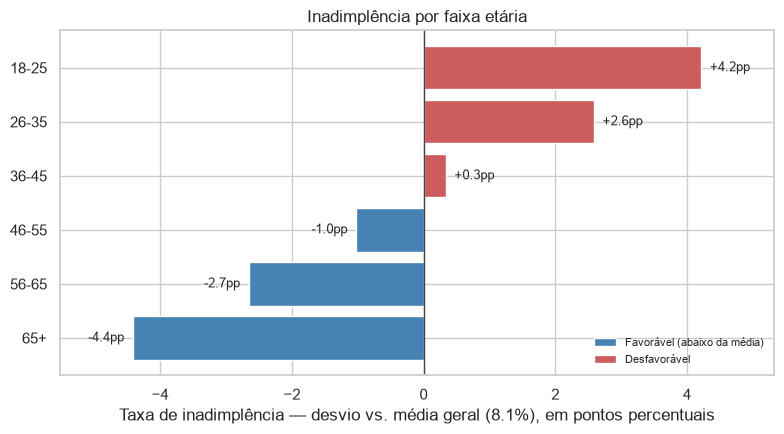

In [13]:
tab_idade_inad = taxa_por_grupo(df, 'FAIXA_ETARIA')
display(tab_idade_inad)
grafico_diferenca_media(tab_idade_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por faixa etária', 'Taxa de inadimplência', acima_e_bom=False)

### 6.3 Por faixa de renda

,n,taxa_pct
FAIXA_RENDA,,
100k-150k,91591,8.62
150k-200k,64307,8.45
Até 100k,63698,8.20
200k-300k,65176,7.55
300k+,22739,5.95


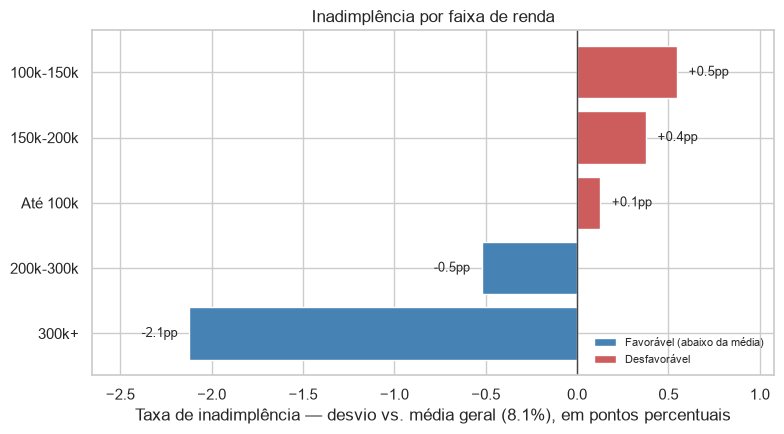

In [14]:
tab_renda_inad = taxa_por_grupo(df, 'FAIXA_RENDA')
display(tab_renda_inad)
grafico_diferenca_media(tab_renda_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por faixa de renda', 'Taxa de inadimplência', acima_e_bom=False)

### 6.4 Por quantidade de filhos

,n,taxa_pct
FAIXA_FILHOS,,
3+,4272,10.04
1,61119,8.92
2,26749,8.72
0,215371,7.71


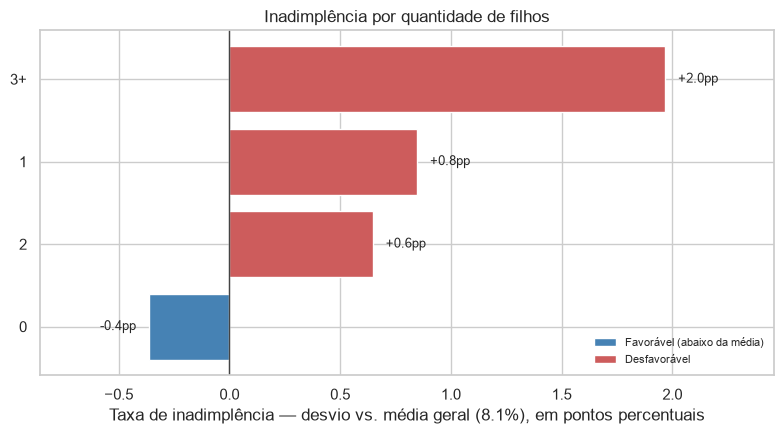

In [15]:
tab_filhos_inad = taxa_por_grupo(df, 'FAIXA_FILHOS')
display(tab_filhos_inad)
grafico_diferenca_media(tab_filhos_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por quantidade de filhos', 'Taxa de inadimplência', acima_e_bom=False)

### 6.5 Por tipo de moradia

,n,taxa_pct
NAME_HOUSING_TYPE,,
Rented apartment,4881,12.31
With parents,14840,11.70
Municipal apartment,11183,8.54
Co-op apartment,1122,7.93
House / apartment,272868,7.80
Office apartment,2617,6.57


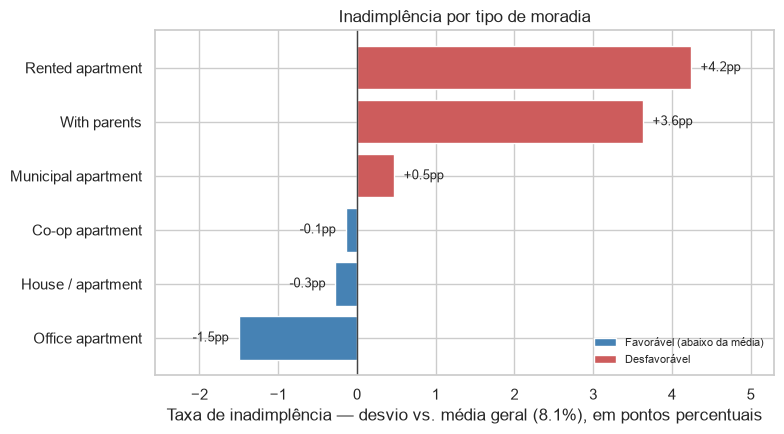

In [16]:
tab_moradia_inad = taxa_por_grupo(df, 'NAME_HOUSING_TYPE')
display(tab_moradia_inad)
grafico_diferenca_media(tab_moradia_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por tipo de moradia', 'Taxa de inadimplência', acima_e_bom=False)

### 6.6 Por produto (contrato atual)

,n,taxa_pct
NAME_CONTRACT_TYPE,,
Cash loans,278232,8.35
Revolving loans,29279,5.48


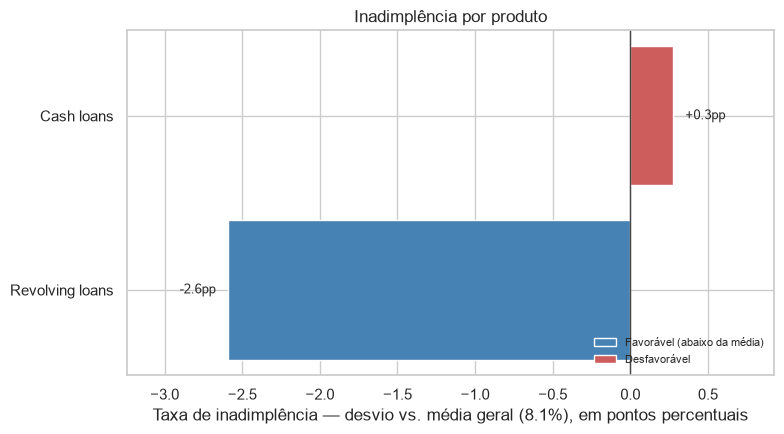

In [17]:
tab_produto_inad = taxa_por_grupo(df, 'NAME_CONTRACT_TYPE')
display(tab_produto_inad)
grafico_diferenca_media(tab_produto_inad['taxa_pct'], taxa_inad_geral,
                         'Inadimplência por produto', 'Taxa de inadimplência', acima_e_bom=False)

### 6.7 Cruzamento: faixa etária x escolaridade

Heatmap da taxa de inadimplência combinando as duas dimensões mais relevantes até aqui (células com menos de 30 clientes são ocultadas por falta de representatividade).

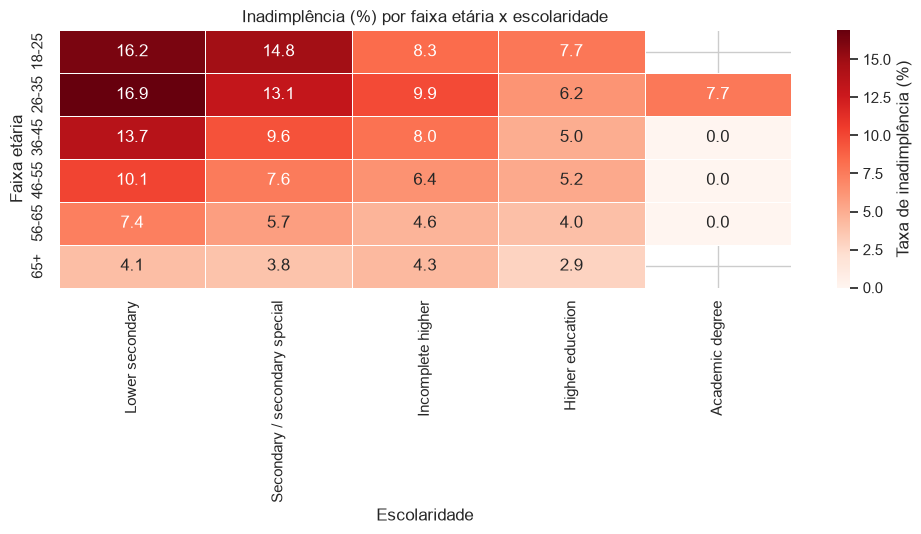

In [18]:
pivot_taxa = df.pivot_table(index='FAIXA_ETARIA', columns='NAME_EDUCATION_TYPE', values='TARGET',
                             aggfunc='mean', observed=True) * 100
pivot_n = df.pivot_table(index='FAIXA_ETARIA', columns='NAME_EDUCATION_TYPE', values='TARGET',
                          aggfunc='count', observed=True)
mascara = pivot_n < 30

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(pivot_taxa, mask=mascara, annot=True, fmt='.1f', cmap='Reds', ax=ax,
            cbar_kws={'label': 'Taxa de inadimplência (%)'}, linewidths=0.5, linecolor='white')
ax.set_title('Inadimplência (%) por faixa etária x escolaridade')
ax.set_xlabel('Escolaridade')
ax.set_ylabel('Faixa etária')
plt.tight_layout()
plt.show()

## 7. Funil de aprovação (previous_application.csv)

`previous_application.csv` traz o histórico de propostas de crédito (não só as concedidas) com o status de cada uma em `NAME_CONTRACT_STATUS`. Cruzando com os dados demográficos de `df`, conseguimos medir a taxa de aprovação real por segmento.

In [19]:
colunas_prev = ['SK_ID_CURR', 'NAME_CONTRACT_STATUS', 'NAME_CONTRACT_TYPE', 'CODE_REJECT_REASON']
df_prev = pd.read_csv(prev_path, sep=',', usecols=colunas_prev)
df_prev = df_prev[df_prev['NAME_CONTRACT_TYPE'] != 'XNA'].copy()

print(f'df_prev: {df_prev.shape[0]} linhas x {df_prev.shape[1]} colunas')
df_prev['NAME_CONTRACT_STATUS'].value_counts()

df_prev: 1669868 linhas x 4 colunas


NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316004
Refused          290647
Unused offer      26436
Name: count, dtype: int64

In [20]:
df_prop = df_prev.merge(
    df[['SK_ID_CURR', 'FAIXA_ETARIA', 'FAIXA_RENDA', 'FAIXA_FILHOS', 'NAME_EDUCATION_TYPE',
        'NAME_HOUSING_TYPE', 'SEXO']],
    on='SK_ID_CURR', how='inner'
)
print(f'Propostas com dados demográficos do cliente: {len(df_prop):,} de {len(df_prev):,} ({len(df_prop)/len(df_prev)*100:.1f}%)'.replace(',', '.'))

Propostas com dados demográficos do cliente: 1.413.388 de 1.669.868 (84.6%)


### 7.1 Distribuição geral das propostas

,qtd,pct
NAME_CONTRACT_STATUS,,
Approved,1036781,62.09
Refused,290647,17.41
Canceled,316004,18.92
Unused offer,26436,1.58


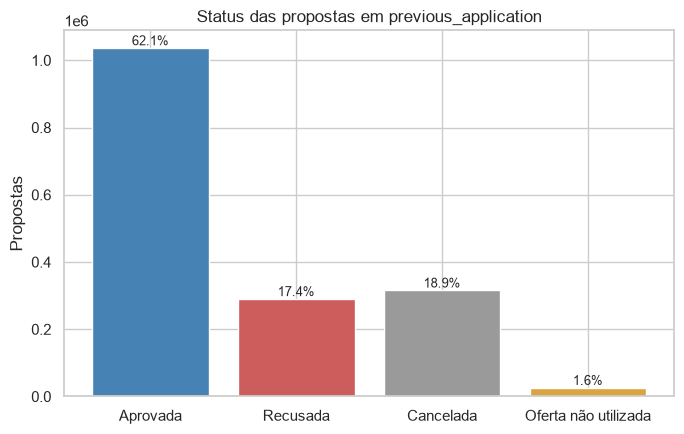

In [21]:
STATUS_ORDEM = ['Approved', 'Refused', 'Canceled', 'Unused offer']
STATUS_CORES = {'Approved': COR_BOM, 'Refused': COR_MAU, 'Canceled': COR_NEUTRA, 'Unused offer': COR_ALERTA}
STATUS_PT = {'Approved': 'Aprovada', 'Refused': 'Recusada', 'Canceled': 'Cancelada', 'Unused offer': 'Oferta não utilizada'}

contagem_status = df_prev['NAME_CONTRACT_STATUS'].value_counts().reindex(STATUS_ORDEM)
pct_status = (contagem_status / contagem_status.sum() * 100).round(2)
display(pd.DataFrame({'qtd': contagem_status, 'pct': pct_status}))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([STATUS_PT[s] for s in STATUS_ORDEM], contagem_status.values,
       color=[STATUS_CORES[s] for s in STATUS_ORDEM])
ax.set_title('Status das propostas em previous_application')
ax.set_ylabel('Propostas')
for i, v in enumerate(contagem_status.values):
    ax.text(i, v, f'{v/contagem_status.sum()*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### 7.2 Taxa de aprovação geral

Definida como `Approved / (Approved + Refused)` — propostas *Canceled* (desistência do cliente) e *Unused offer* (oferta aprovada, mas não utilizada) não refletem uma decisão de crédito e ficam de fora do denominador.

In [22]:
df_decidido = df_prop[df_prop['NAME_CONTRACT_STATUS'].isin(['Approved', 'Refused'])].copy()
df_decidido['APROVADO'] = (df_decidido['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)

taxa_aprov_geral = df_decidido['APROVADO'].mean() * 100
print(f'Taxa de aprovação geral: {taxa_aprov_geral:.2f}%')
print(f'Base: {len(df_decidido):,} propostas decididas (Approved + Refused)'.replace(',', '.'))

Taxa de aprovação geral: 78.31%
Base: 1.131.460 propostas decididas (Approved + Refused)


### 7.3 Por produto

,n,taxa_pct
NAME_CONTRACT_TYPE,,
Consumer loans,601592,89.31
Revolving loans,123919,66.50
Cash loans,405949,65.62


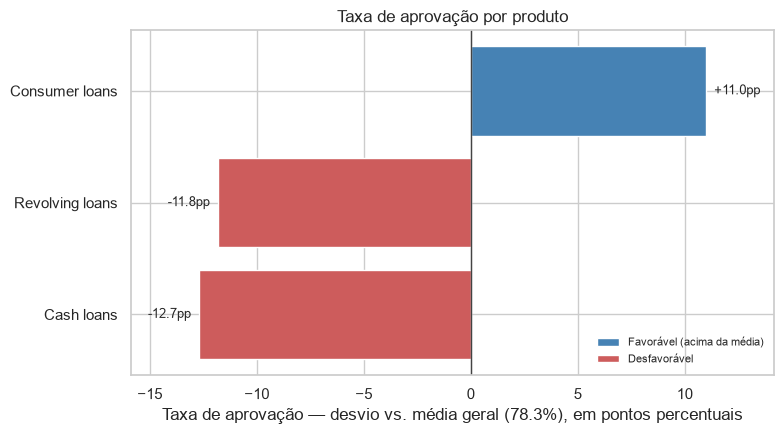

In [23]:
tab_produto_aprov = taxa_por_grupo(df_decidido, 'NAME_CONTRACT_TYPE', target='APROVADO')
display(tab_produto_aprov)
grafico_diferenca_media(tab_produto_aprov['taxa_pct'], taxa_aprov_geral,
                         'Taxa de aprovação por produto', 'Taxa de aprovação', acima_e_bom=True)

### 7.4 Por escolaridade

,n,taxa_pct
NAME_EDUCATION_TYPE,,
Academic degree,509,82.12
Lower secondary,13900,78.63
Secondary / secondary special,831691,78.40
Higher education,249049,78.30
Incomplete higher,36311,76.22


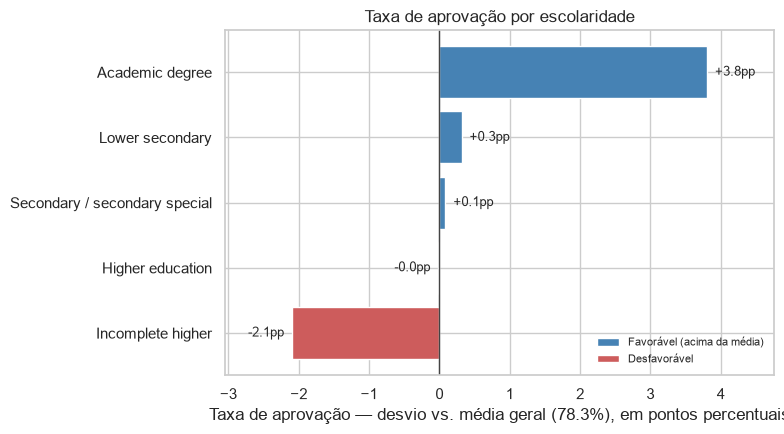

In [24]:
tab_edu_aprov = taxa_por_grupo(df_decidido, 'NAME_EDUCATION_TYPE', target='APROVADO')
display(tab_edu_aprov)
grafico_diferenca_media(tab_edu_aprov['taxa_pct'], taxa_aprov_geral,
                         'Taxa de aprovação por escolaridade', 'Taxa de aprovação', acima_e_bom=True)

### 7.5 Por faixa etária

,n,taxa_pct
FAIXA_ETARIA,,
65+,33307,84.11
36-45,312833,79.13
46-55,258743,78.50
56-65,234772,78.03
26-35,259103,76.92
18-25,32702,76.35


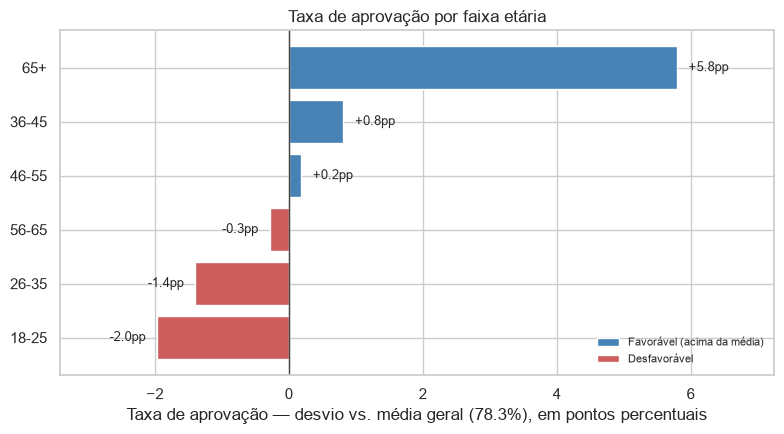

In [25]:
tab_idade_aprov = taxa_por_grupo(df_decidido, 'FAIXA_ETARIA', target='APROVADO')
display(tab_idade_aprov)
grafico_diferenca_media(tab_idade_aprov['taxa_pct'], taxa_aprov_geral,
                         'Taxa de aprovação por faixa etária', 'Taxa de aprovação', acima_e_bom=True)

### 7.6 Por quantidade de filhos

,n,taxa_pct
FAIXA_FILHOS,,
1,217853,79.51
2,98402,79.43
3+,16261,79.07
0,798944,77.84


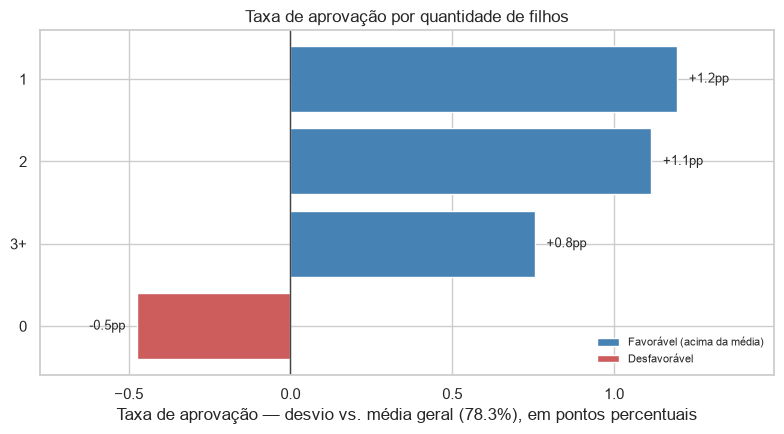

In [26]:
tab_filhos_aprov = taxa_por_grupo(df_decidido, 'FAIXA_FILHOS', target='APROVADO')
display(tab_filhos_aprov)
grafico_diferenca_media(tab_filhos_aprov['taxa_pct'], taxa_aprov_geral,
                         'Taxa de aprovação por quantidade de filhos', 'Taxa de aprovação', acima_e_bom=True)

### 7.7 Por tipo de moradia

,n,taxa_pct
NAME_HOUSING_TYPE,,
Co-op apartment,3447,80.88
Municipal apartment,41682,79.50
Office apartment,9323,78.50
House / apartment,1010941,78.31
Rented apartment,16122,78.20
With parents,49945,77.24


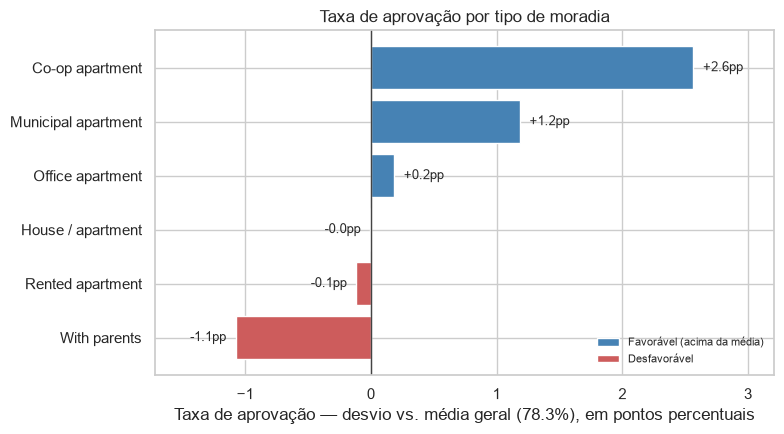

In [27]:
tab_moradia_aprov = taxa_por_grupo(df_decidido, 'NAME_HOUSING_TYPE', target='APROVADO')
display(tab_moradia_aprov)
grafico_diferenca_media(tab_moradia_aprov['taxa_pct'], taxa_aprov_geral,
                         'Taxa de aprovação por tipo de moradia', 'Taxa de aprovação', acima_e_bom=True)

### 7.8 Bônus: principais motivos de recusa

`CODE_REJECT_REASON` é um código interno da Home Credit sem dicionário oficial público — os valores abaixo são mantidos como códigos brutos (não convertidos), servindo apenas para ver a concentração dos motivos de recusa.

,qtd,pct
CODE_REJECT_REASON,,
HC,175202,60.3
LIMIT,55680,19.2
SCO,37467,12.9
SCOFR,12811,4.4
XNA,5234,1.8
VERIF,3535,1.2
SYSTEM,717,0.2
XAP,1,0.0


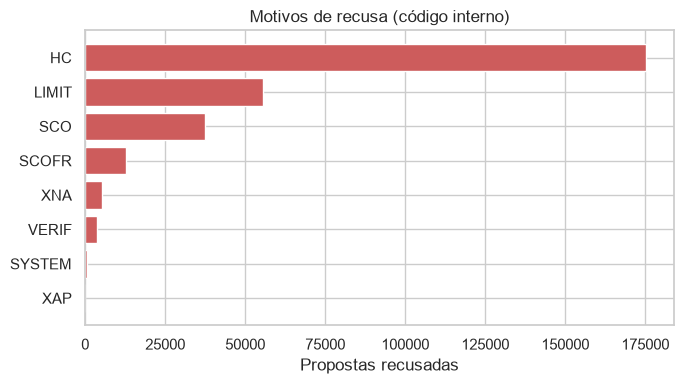

In [28]:
recusados = df_prev[df_prev['NAME_CONTRACT_STATUS'] == 'Refused']
motivos = recusados['CODE_REJECT_REASON'].value_counts()
motivos_pct = (motivos / motivos.sum() * 100).round(1)
display(pd.DataFrame({'qtd': motivos, 'pct': motivos_pct}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(motivos.index[::-1], motivos.values[::-1], color=COR_MAU)
ax.set_title('Motivos de recusa (código interno)')
ax.set_xlabel('Propostas recusadas')
plt.tight_layout()
plt.show()

## 8. Aprovação x Risco

Cruzando as duas análises: será que os segmentos mais aprovados são também os de menor risco? O quadrante ideal é **aprovação alta + inadimplência baixa** (canto inferior direito); o de maior atenção é **aprovação alta + inadimplência alta** (canto superior direito).

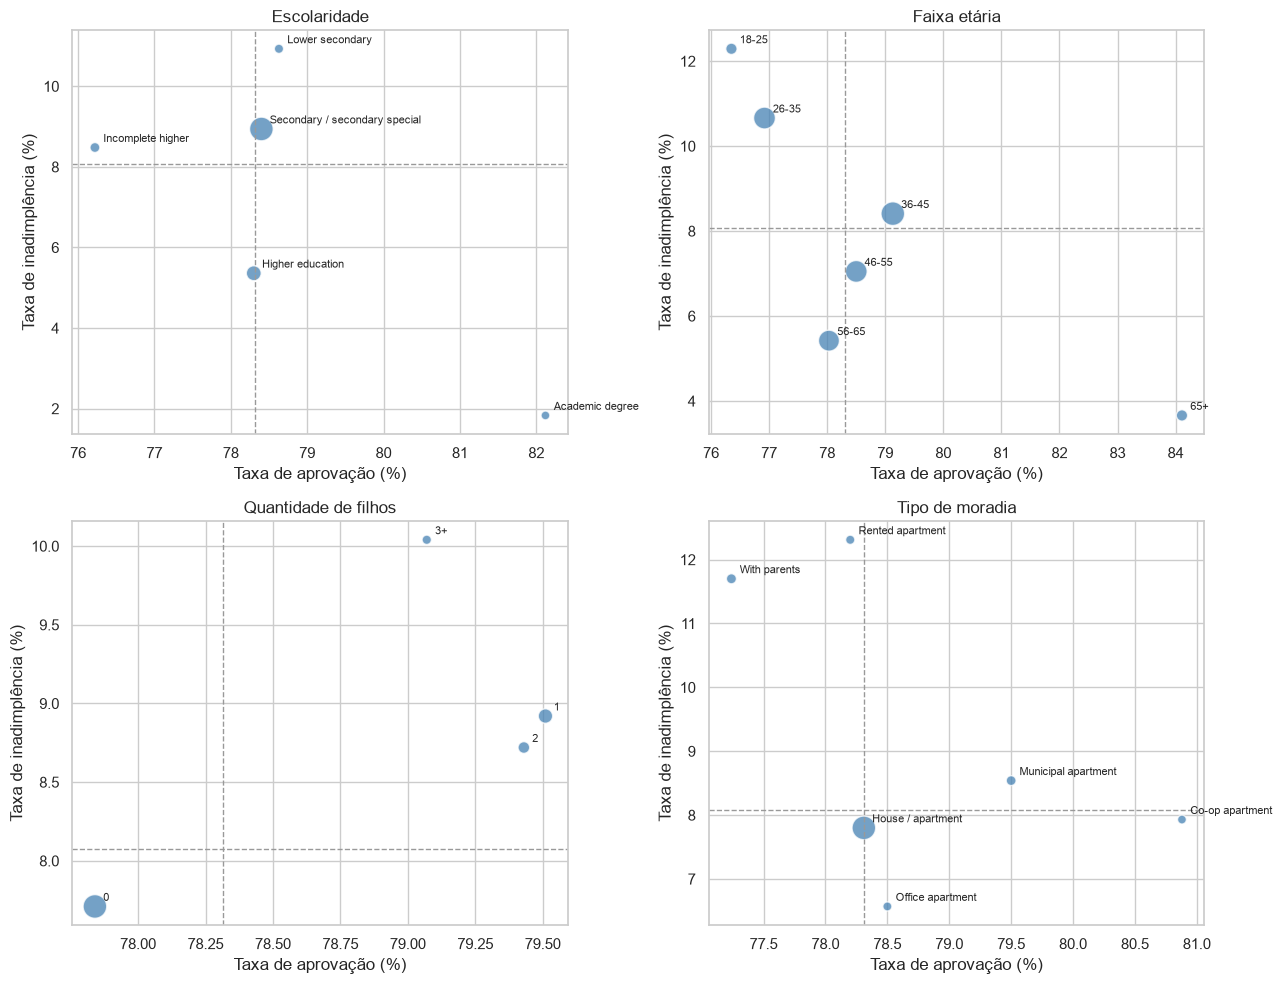

In [ ]:
def tabela_combinada(dim):
    aprov = taxa_por_grupo(df_decidido, dim, target='APROVADO')[['taxa_pct', 'n']]
    aprov = aprov.rename(columns={'taxa_pct': 'taxa_aprovacao', 'n': 'n_propostas'})
    inad = taxa_por_grupo(df, dim, target='TARGET')[['taxa_pct', 'n']]
    inad = inad.rename(columns={'taxa_pct': 'taxa_inadimplencia', 'n': 'n_clientes'})
    return aprov.join(inad, how='inner')


def scatter_aprovacao_risco(ax, tab, titulo, media_aprov, media_inad):
    tamanhos = 250 * (tab['n_propostas'] / tab['n_propostas'].max()) + 40
    ax.scatter(tab['taxa_aprovacao'], tab['taxa_inadimplencia'], s=tamanhos,
               color=COR_BOM, alpha=0.75, edgecolor='white', linewidth=1)
    for idx, row in tab.iterrows():
        ax.annotate(str(idx), (row['taxa_aprovacao'], row['taxa_inadimplencia']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.axvline(media_aprov, color='#999999', linestyle='--', linewidth=1)
    ax.axhline(media_inad, color='#999999', linestyle='--', linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel('Taxa de aprovação (%)')
    ax.set_ylabel('Taxa de inadimplência (%)')


dimensoes = {
    'Escolaridade': 'NAME_EDUCATION_TYPE',
    'Faixa etária': 'FAIXA_ETARIA',
    'Quantidade de filhos': 'FAIXA_FILHOS',
    'Tipo de moradia': 'NAME_HOUSING_TYPE',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (titulo, dim) in zip(axes.reshape(-1), dimensoes.items()):
    tab = tabela_combinada(dim)
    scatter_aprovacao_risco(ax, tab, titulo, taxa_aprov_geral, taxa_inad_geral)

plt.tight_layout()
plt.show()

## 9. Conclusões e próximos passos

- **Público majoritário:** mulheres, casadas, sem filhos, com escolaridade secundária, morando em casa/apartamento próprio — perfil que também concentra o maior volume de propostas.
- **Inadimplência não é uniforme:** cai de forma consistente com o nível de escolaridade (quanto maior o grau, menor o TARGET) e com a renda; sobe entre clientes mais jovens, sem imóvel próprio e morando com os pais ou de aluguel — indício de menor estabilidade financeira nesses segmentos.
- **Aprovação varia mais por produto do que por perfil demográfico:** a maior diferença encontrada foi entre tipos de produto em `previous_application` (consumo vs. crédito em dinheiro/rotativo), enquanto os recortes de escolaridade, idade, filhos e moradia mostram taxas de aprovação bem mais próximas entre si.
- **Aprovação x risco:** de forma geral, os segmentos com maior taxa de aprovação não são os de maior inadimplência — sugerindo que a política de concessão já incorpora, ainda que parcialmente, o risco observado nesses recortes.

## Com isso: 

-> Já tenho um mapeamento prévio do meu público, perfil de atraso e variáveis que mais "impactantes"

### Objetivo
    - Conceder mais crédito, controlando a inadimplência